# Pima Indians Diabetes Prediction - MLP

This notebook explores the Pima Indians Diabetes Dataset and builds a Multi-Layer Perceptron (MLP) model using TensorFlow/Keras to predict the onset of diabetes. This neural network approach is explored after testing traditional tree-based classification models.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading and Exploration
Load the dataset and perform an initial exploratory data analysis to understand its structure, missing values, and summary statistics.

In [26]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [28]:
df.describe().round()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.0,768.0,768.0,768.0,768.0,768.0,768.0,768.0,768.0
mean,4.0,121.0,69.0,21.0,80.0,32.0,0.0,33.0,0.0
std,3.0,32.0,19.0,16.0,115.0,8.0,0.0,12.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.0,0.0
25%,1.0,99.0,62.0,0.0,0.0,27.0,0.0,24.0,0.0
50%,3.0,117.0,72.0,23.0,30.0,32.0,0.0,29.0,0.0
75%,6.0,140.0,80.0,32.0,127.0,37.0,1.0,41.0,1.0
max,17.0,199.0,122.0,99.0,846.0,67.0,2.0,81.0,1.0


In [29]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.columns

Index(['pregnancies', 'glucose', 'bloodpressure', 'skinthickness', 'insulin',
       'bmi', 'diabetespedigreefunction', 'age', 'outcome'],
      dtype='str')

In [30]:
df.outcome.value_counts()

outcome
0    500
1    268
Name: count, dtype: int64

## 2. Data Preprocessing

### 2.1 Handling Missing Values
Several columns have a value of `0` where it is biologically impossible (e.g., blood pressure, BMI). We treat these as missing values (`NaN`) and replace them with the median of their respective columns.

In [31]:
cols = ['glucose','bloodpressure', 'skinthickness', 'insulin', 'bmi']
df[cols] = df[cols].replace(0, np.nan)

In [32]:
df.isnull().sum()

pregnancies                   0
glucose                       5
bloodpressure                35
skinthickness               227
insulin                     374
bmi                          11
diabetespedigreefunction      0
age                           0
outcome                       0
dtype: int64

In [33]:
cols = ['glucose','bloodpressure', 'skinthickness', 'insulin', 'bmi']
for col in cols:
    df[col]=df[col].replace(np.nan, df[col].median())

### 2.2 Data Splitting & Resampling
Split the dataset into training, validation, and test sets. Since the target variable is imbalanced, we perform upsampling on the minority class to balance the training data, and apply standard scaling to all input features for neural network compatibility.

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler

In [35]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=5)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=5)

In [36]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [37]:
df_train.outcome.value_counts()

outcome
0    305
1    155
Name: count, dtype: int64

In [38]:
max = df_train[df_train.outcome==0]
min = df_train[df_train.outcome==1]
upsample = resample(min, replace=True, n_samples=305, random_state=7)
df_train = pd.concat([upsample, max])

In [39]:
y_train = df_train.outcome
y_val = df_val.outcome
y_test = df_test.outcome

In [40]:
df_train.outcome.value_counts()

outcome
1    305
0    305
Name: count, dtype: int64

In [41]:
del df_train['outcome']
del df_val['outcome']
del df_test['outcome']

In [42]:
len(df_train), len(df_test), len(df_val)

(610, 154, 154)

In [43]:
X_train = df_train
X_val = df_val
X_test = df_test


In [44]:
y_train.value_counts()

outcome
1    305
0    305
Name: count, dtype: int64

In [46]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## 3. Model Training

### 3.1 Initial MLP Model
Train an initial Multi-Layer Perceptron with two hidden layers (16 and 8 neurons). We compile the model using the Adam optimizer and monitor both training and validation performance to check for overfitting.

In [58]:
import keras

In [59]:
model = keras.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid'),
    ])

In [60]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.5525 - loss: 0.6945 - val_accuracy: 0.6688 - val_loss: 0.6335
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6148 - loss: 0.6499 - val_accuracy: 0.7208 - val_loss: 0.6073
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6820 - loss: 0.6192 - val_accuracy: 0.7273 - val_loss: 0.5866
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6902 - loss: 0.5977 - val_accuracy: 0.7143 - val_loss: 0.5669
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7000 - loss: 0.5782 - val_accuracy: 0.7273 - val_loss: 0.5506
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7115 - loss: 0.5633 - val_accuracy: 0.7403 - val_loss: 0.5413
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7115 - loss: 0.5532 - val_accuracy: 0.7273 - val_loss: 0.5309
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7230 - loss: 0.5429 - val_accuracy: 0.733

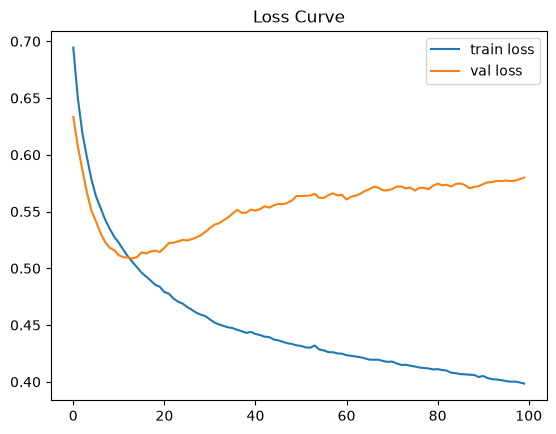

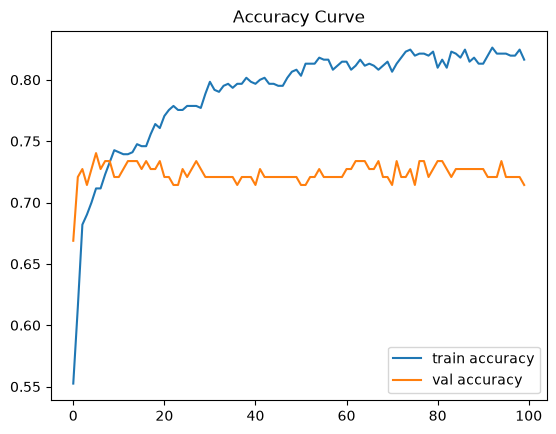

In [63]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

### 3.2 Regularized MLP Model
The initial learning curves indicate signs of overfitting. We introduce Dropout (0.3 rate) and Early Stopping to prevent the network from memorizing the training data, and retrain the model to improve generalization.

In [67]:
from keras.layers import Dropout
from keras.callbacks import EarlyStopping

In [66]:
model = keras.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid'),
    ])

In [69]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [70]:
earlystop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True)
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[earlystop],
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.5098 - loss: 0.8256 - val_accuracy: 0.5974 - val_loss: 0.6860
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5230 - loss: 0.7325 - val_accuracy: 0.6558 - val_loss: 0.6505
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5344 - loss: 0.7050 - val_accuracy: 0.6753 - val_loss: 0.6305
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5590 - loss: 0.6798 - val_accuracy: 0.6948 - val_loss: 0.6137
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5656 - loss: 0.6586 - val_accuracy: 0.6818 - val_loss: 0.6000
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6410 - loss: 0.6245 - val_accuracy: 0.6623 - val_loss: 0.5912
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6492 - loss: 0.6255 - val_accuracy: 0.6429 - val_loss: 0.5825
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6377 - loss: 0.6004 - val_accuracy: 0.6

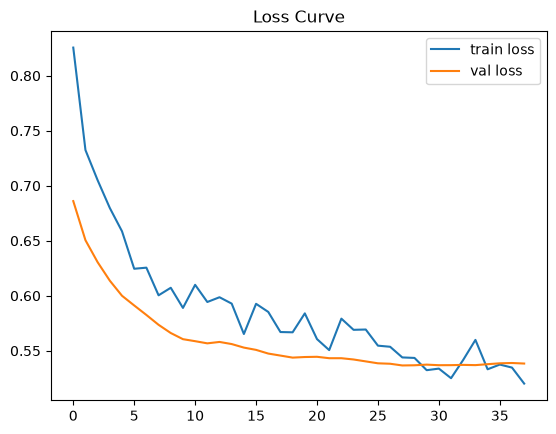

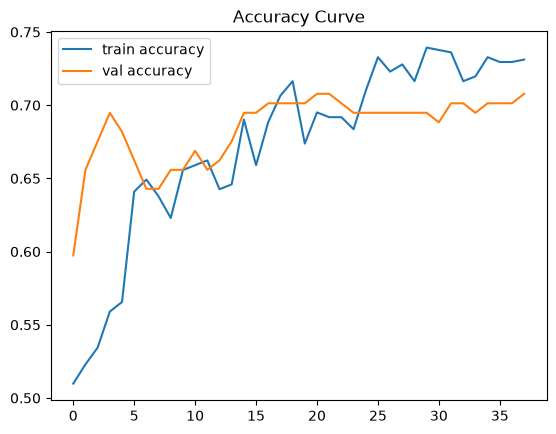

In [71]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

## 4. Final Evaluation and Results
Evaluate the final regularized MLP model against the unseen test set using Accuracy, ROC-AUC, Confusion Matrix, and Classification Reports.

In [72]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, classification_report

In [73]:
y_pred_prob = model.predict(X_test_scaled)
y_pred_labels = (y_pred_prob >= 0.5).astype(int)

print("Accuracy: ", accuracy_score(y_test, y_pred_labels))
print("ROC-AUC: ", roc_auc_score(y_test, y_pred_prob))
print("\nConfusion Matrix: \n ", confusion_matrix(y_test, y_pred_labels))
print("\nClassification Report: \n ", classification_report(y_test, y_pred_labels))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Accuracy:  0.7532467532467533
ROC-AUC:  0.8405555555555556

Confusion Matrix: 
  [[71 29]
 [ 9 45]]

Classification Report: 
                precision    recall  f1-score   support

           0       0.89      0.71      0.79       100
           1       0.61      0.83      0.70        54

    accuracy                           0.75       154
   macro avg       0.75      0.77      0.75       154
weighted avg       0.79      0.75      0.76       154



### Conclusion
Based on the final evaluation on the test set, the regularized MLP model achieved an accuracy of ~75.3% and a strong ROC-AUC score of ~0.84. The addition of Dropout and Early Stopping successfully mitigated overfitting, resulting in a reliable model for distinguishing between the two classes.
